Dataset Shape: (891, 12)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Cleaned Dataset:
   PassengerId  Survived  Pclass  Sex       Age  SibSp  Parch      Fare  \
0            1         0       3    1 -0.565736      1      0 -0.502445   
1            2         1       1    0  0.663861      1      0  0.786845   
2            3         1       3    0 -0.258337      0      0 -0.488854   
3            4         1       1    0  0.433312      1      0  0.420730   
4            5         0       3    1  0.433312      0      0 -0.486337   

   Embarked  
0         2  
1         0  
2         2  
3         2  
4         2  


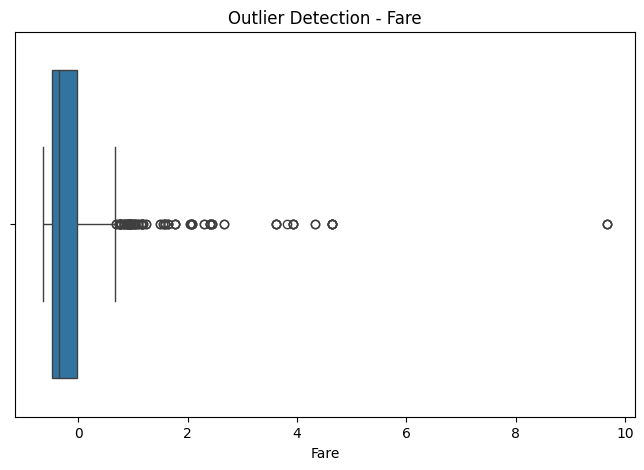

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task completed successfully!


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Upload your Titanic-Dataset.csv file
uploaded = files.upload()

# Read dataset
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column if present
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

# Encode categorical columns
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Drop unnecessary text columns
df.drop(['Name', 'Ticket'], axis=1, inplace=True)

# Standardize Age and Fare
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Show first rows
print("\nCleaned Dataset:")
print(df.head())

# Boxplot for outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Outlier Detection - Fare")
plt.show()

# Save cleaned dataset
df.to_csv("cleaned_titanic.csv", index=False)

# Download cleaned dataset
files.download("cleaned_titanic.csv")

print("Task completed successfully!")